In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# choose which one you want to use/ customize this section for your own file system.

# url = "https://drive.google.com/file/d/1-T4dkpwBNuxPtKu3yvEcs8RPVoOX2Gkv/view?usp=sharing"
# url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
# imdb = pd.read_csv(url)

imdb = pd.read_csv("movie-data/Imdb_Movie_Dataset.csv")

In [3]:
print(imdb.head(25).to_string())

        id                                              title  vote_average  vote_count    status release_date     revenue  runtime  adult     budget    imdb_id original_language                                     original_title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    overview  popularity                                                                                 tagline                                       genres                                                                                                                 production_companies 

In [4]:
# Counting the number of rows in the dataset.
# .shape[0] gives the number of rows and [1] is columns.

num_rows = imdb.shape[0]
num_cols = imdb.shape[1]
print(num_rows)
print(num_cols)

1048575
21


In [5]:
# Checks how many values in each column are unique.

unique_column_values = imdb.nunique(0)

print(unique_column_values)

id                      1047781
title                    903262
vote_average               5024
vote_count                 3598
status                        6
release_date              42375
revenue                   14242
runtime                     741
adult                         2
budget                     5586
imdb_id                  559319
original_language           172
original_title           933950
overview                 808624
popularity                19833
tagline                  146892
genres                    13117
production_companies     197343
production_countries       9723
spoken_languages           6839
keywords                 170704
dtype: int64


In [6]:
# Sorting the dataset by ID because the ID has the least number of duplicates.
srt_ID_df = imdb.copy()
srt_ID_df = srt_ID_df.sort_values(by="id", ascending=True)

print(srt_ID_df.head(25).to_string())

       id                                                   title  vote_average  vote_count    status release_date    revenue  runtime  adult     budget    imdb_id original_language                                          original_title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [7]:
# This shows all the entries which are duplicates.
duplicate_IDs = srt_ID_df[srt_ID_df.duplicated(subset=['id'], keep=False)]
print(duplicate_IDs)


             id                           title  vote_average  vote_count  \
722297  1192939  Soldiers from Eastern Europe 6           0.0           0   
722298  1192939  Soldiers from Eastern Europe 6           0.0           0   
722299  1192939  Soldiers from Eastern Europe 6           0.0           0   
722300  1192939  Soldiers from Eastern Europe 6           0.0           0   
722302  1192940                              杀夫           0.0           0   
...         ...                             ...           ...         ...   
459954  1409643     Abel Ernest Tembo's Suspect           0.0           0   
467911  1410107   Older Women & Younger Women 5           0.0           0   
467892  1410107   Older Women & Younger Women 5           0.0           0   
465794  1410516                     Yegna Neger           0.0           0   
467456  1410516                     Yegna Neger           0.0           0   

               status release_date  revenue  runtime  adult  budget  ...  \

In [8]:
# We should combine the duplicates into one entry for each duplicate.

In [9]:
# This lists how many missing values exist for each column.
missing_values_in_columns = srt_ID_df.isna().sum()
print(missing_values_in_columns)

id                           0
title                       13
vote_average                 0
vote_count                   0
status                       0
release_date            181817
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                 488003
original_language            0
original_title              13
overview                215824
popularity                   0
tagline                 895847
genres                  414972
production_companies    568428
production_countries    463497
spoken_languages        440662
keywords                755954
dtype: int64


In [10]:
# We need to figure out what to do about these missing values!

In [11]:
# Removing columns that are more than 50% empty.

column_names_list = srt_ID_df.columns.tolist()
print(column_names_list)

num_columns = srt_ID_df.shape[0]
fifty_pcnt = int(num_columns / 2)
dropped_missing_df = srt_ID_df.copy()

for column, mssng_count in missing_values_in_columns.items():
    if mssng_count > fifty_pcnt:
        print(f"Removed Column: {column}\n    Missing Count: {mssng_count}")
        dropped_missing_df = dropped_missing_df.drop(column, axis=1)

column_names_list = dropped_missing_df.columns.tolist()
print(column_names_list)

['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']
Removed Column: tagline
    Missing Count: 895847
Removed Column: production_companies
    Missing Count: 568428
Removed Column: keywords
    Missing Count: 755954
['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'genres', 'production_countries', 'spoken_languages']


In [12]:
missing_values_in_columns = dropped_missing_df.isna().sum()
print(missing_values_in_columns)

id                           0
title                       13
vote_average                 0
vote_count                   0
status                       0
release_date            181817
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                 488003
original_language            0
original_title              13
overview                215824
popularity                   0
genres                  414972
production_countries    463497
spoken_languages        440662
dtype: int64


In [13]:
# Checking the column datatypes.
# This will help us determine Numerical, Categorical, Binary, etc. for the data.
column_types = dropped_missing_df.dtypes
print(column_types)


id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
budget                    int64
imdb_id                  object
original_language        object
original_title           object
overview                 object
popularity              float64
genres                   object
production_countries     object
spoken_languages         object
dtype: object


In [14]:
unique_column_values = dropped_missing_df.nunique(0)
print(unique_column_values)

id                      1047781
title                    903262
vote_average               5024
vote_count                 3598
status                        6
release_date              42375
revenue                   14242
runtime                     741
adult                         2
budget                     5586
imdb_id                  559319
original_language           172
original_title           933950
overview                 808624
popularity                19833
genres                    13117
production_countries       9723
spoken_languages           6839
dtype: int64


In [15]:
numerical_columns = ["id", "vote_average", "vote_count", "revenue", "runtime", "budget", "popularity"]
categorical_columns = ["original_language", "genres", "production_countries", "spoken_languages"]
binary_columns = ["status", "adult"]
ordinal_columns = [""]
text_columns = ["text", "release_date", "original_title", "overview"]
# Left out: imdb_id


In [16]:
status_unique_values = dropped_missing_df["status"].unique()
print(status_unique_values)


['Released' 'Post Production' 'Rumored' 'Canceled' 'Planned'
 'In Production']


In [17]:
# the binary column Adult is converted to 0 = False and 1 = True.
converted_adult_df = dropped_missing_df.copy()

converted_adult_df["adult"] = converted_adult_df["adult"].astype(int)

print(converted_adult_df["adult"])


9847      0
9368      0
1819      0
8939      0
42892     0
         ..
466709    0
466653    0
464765    1
465881    0
466536    1
Name: adult, Length: 1048575, dtype: int32


In [18]:
# Think of doing one-hot OR Ordinal encoding for the Status column.

In [61]:
cleaned_df = converted_adult_df.copy()

count   1048575.0000
mean         48.2261
std          60.5782
min         -28.0000
25%           0.0000
50%          23.0000
75%          89.0000
max       14400.0000
Name: runtime, dtype: float64


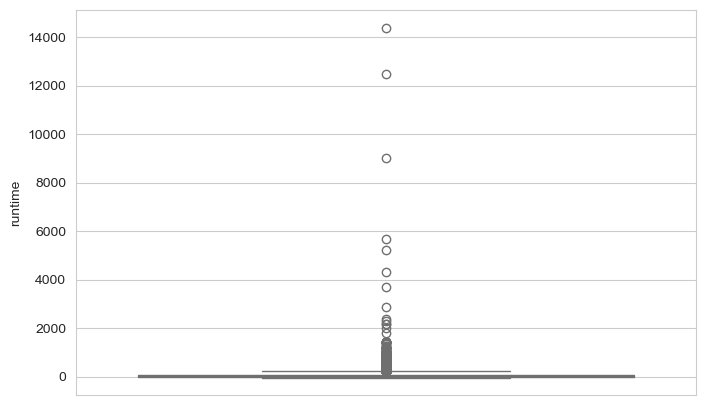

In [33]:
# Runtime data

pd.set_option('display.float_format', '{:.4f}'.format)
print(cleaned_df["runtime"].describe())

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
# sns.boxplot(x=cleaned_df["runtime"], color="skyblue")
sns.boxplot(cleaned_df["runtime"], color="skyblue")
plt.show()


count      1048575.0000
mean        760411.2047
std       19449249.1097
min            -12.0000
25%              0.0000
50%              0.0000
75%              0.0000
max     4999999999.0000
Name: revenue, dtype: float64


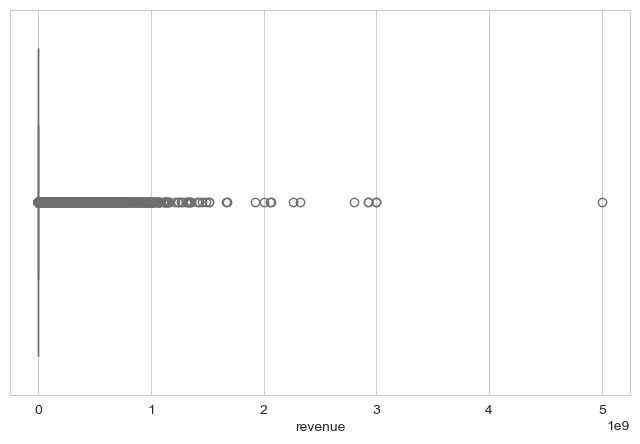

In [34]:
# Revenue data

pd.set_option('display.float_format', '{:.4f}'.format)
print(cleaned_df["revenue"].describe())

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.boxplot(x=cleaned_df["revenue"], color="skyblue")
plt.show()

In [64]:
# Turns release date into a number instead of text.
# The dates are converted into a Unix timestamp.

print(cleaned_df["release_date"])

cleaned_df["release_date"] = pd.to_datetime(cleaned_df["release_date"], format="mixed")

print(cleaned_df["release_date"])

1821       2/6/1927
20906      2/5/2004
4068      2/14/1997
1489      2/20/1985
16167     2/10/2006
            ...    
466546    2/27/2021
467239    2/13/2021
465701    2/19/2021
467150    2/21/2023
466944    2/28/2025
Name: release_date, Length: 51681, dtype: object
1821     1927-02-06
20906    2004-02-05
4068     1997-02-14
1489     1985-02-20
16167    2006-02-10
            ...    
466546   2021-02-27
467239   2021-02-13
465701   2021-02-19
467150   2023-02-21
466944   2025-02-28
Name: release_date, Length: 51681, dtype: datetime64[ns]


C:\Users\MLad\AppData\Local\Temp\ipykernel_19752\3026818162.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


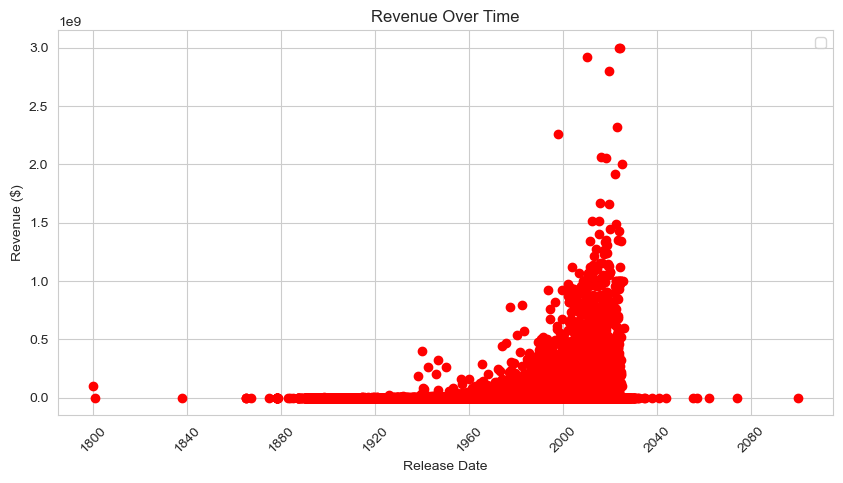

In [37]:
# revenue over time graph

plt.figure(figsize=(10,5))  # Set figure size

# marker='o', linestyle='-', color='b', label='Revenue'
plt.plot(cleaned_df['release_date'], cleaned_df['revenue'], 'ro')

# Formatting
plt.xlabel('Release Date')
plt.ylabel('Revenue ($)')
plt.title('Revenue Over Time')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.legend()

# Show the plot
plt.show()


In [65]:
cleaned_df = cleaned_df[cleaned_df["release_date"] >= '1900-01-01']
cleaned_df = cleaned_df[cleaned_df["release_date"] < '2024-01-01']

C:\Users\MLad\AppData\Local\Temp\ipykernel_19752\592347747.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


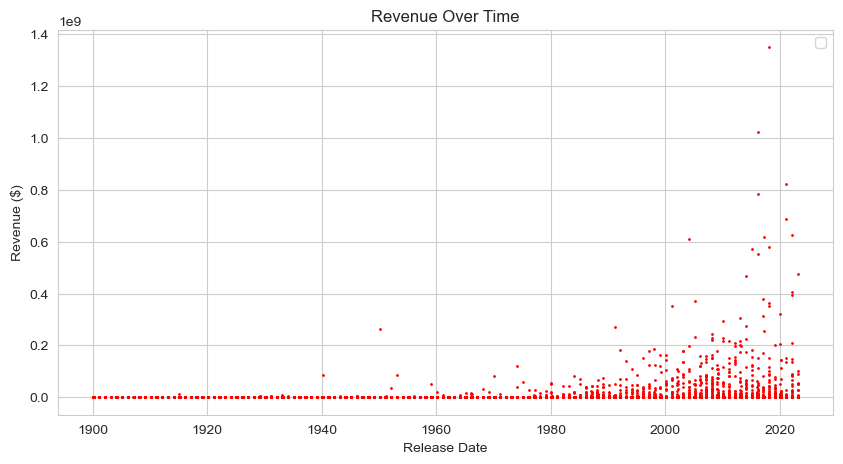

In [68]:
# revenue over time graph

pd.set_option('display.float_format', '{:.4f}'.format)

plt.figure(figsize=(10,5))  # Set figure size

# marker='o', linestyle='-', color='b', label='Revenue'
plt.plot(cleaned_df['release_date'], cleaned_df['revenue'], 'ro', ms=1)

# Formatting
plt.xlabel('Release Date')
plt.ylabel('Revenue ($)')
# plt.yscale("log")
plt.title('Revenue Over Time')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'vote_average'}>,
        <Axes: title={'center': 'vote_count'}>],
       [<Axes: title={'center': 'release_date'}>,
        <Axes: title={'center': 'revenue'}>,
        <Axes: title={'center': 'runtime'}>],
       [<Axes: title={'center': 'adult'}>,
        <Axes: title={'center': 'budget'}>,
        <Axes: title={'center': 'popularity'}>]], dtype=object)

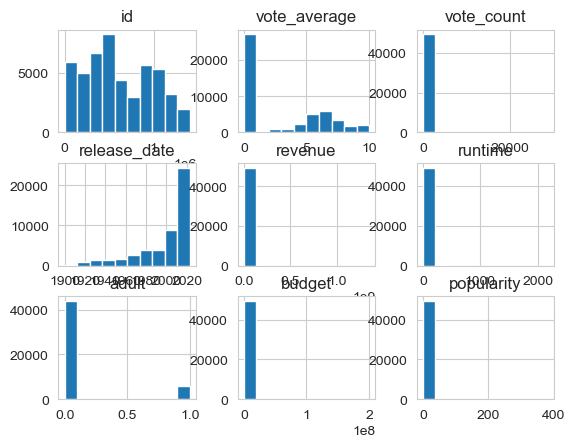

In [69]:
cleaned_df.hist()

In [70]:
cleaned_df.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,adult,budget,popularity
count,49413.0000,49413.0000,49413.0000,49413,49413.0000,49413.0000,49413.0000,49413.0000,49413.0000
mean,613619.3515,2.7455,28.0662,1998-11-18 14:50:43.749620352,850886.9616,61.2988,0.1148,353383.3811,1.5827
min,19.0000,0.0000,0.0000,1900-02-01 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000
25%,316360.0000,0.0000,0.0000,1987-02-12 00:00:00,0.0000,6.0000,0.0000,0.0000,0.6000
50%,538526.0000,0.0000,0.0000,2010-02-17 00:00:00,0.0000,66.0000,0.0000,0.0000,0.6000
75%,943101.0000,6.0000,2.0000,2018-02-16 00:00:00,0.0000,96.0000,0.0000,0.0000,1.1950
max,1410865.0000,10.0000,28894.0000,2023-02-28 00:00:00,1349926083.0000,2182.0000,1.0000,200000000.0000,383.6030
std,379411.2902,3.2804,360.6797,NaN,15327358.3395,58.9726,0.3188,4457506.9235,4.9870


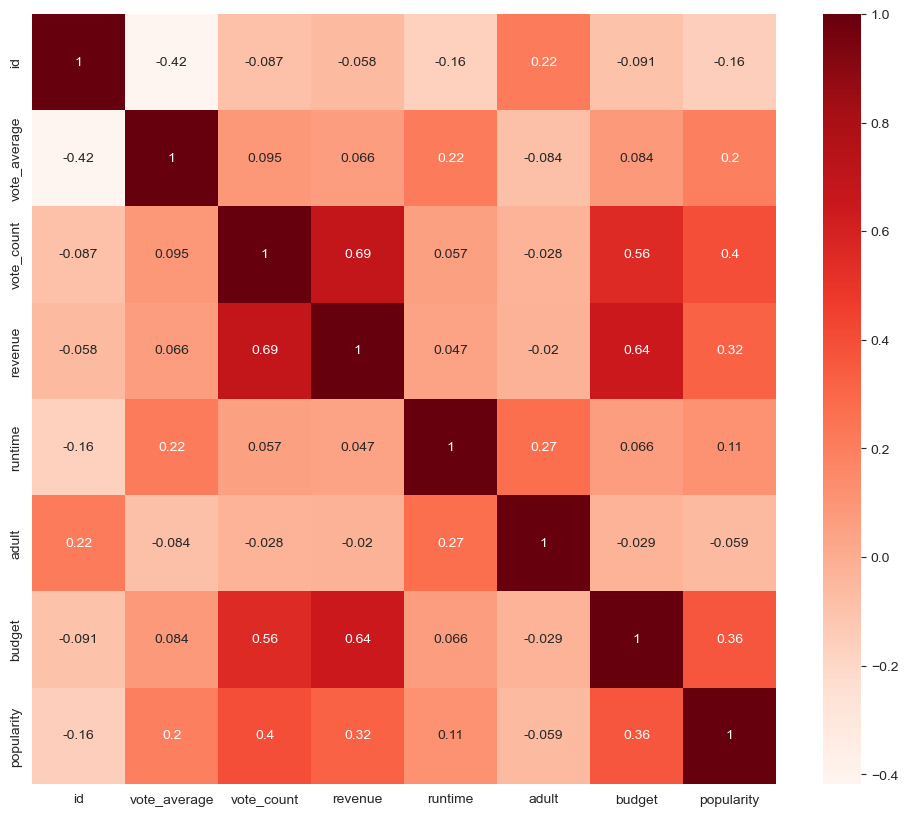

In [72]:
numeric_df = cleaned_df.select_dtypes(include=["number"])

plt.figure(figsize=(12,10))
# cleaned_df.corr() # default method ='pearson' correlation coefficent
sns.heatmap(numeric_df.corr(), annot=True, cmap=plt.cm.Reds)
plt.show()


In [22]:

"""
Figure out:
  - Key data cleaning methods
  - Key data encoding methods
  - Key Features




"""

'\nFigure out:\n  - Key data cleaning methods\n  - Key data encoding methods\n  - Key Features\n\n\n\n\n'

In [23]:
# New dataset??
# 
# https://developer.imdb.com/non-commercial-datasets/
# 
# 
# 